## What we have

For each slice, we identify clusters in both the radiance and temperature data, then match the corresponding clusters between the temperature and radiance.

For each matched cluster, we currently have the following 1200 × 600 fields:

* Cluster Reconstruction
* Amplitude
* Dominant Wavelength
* Angle
* Temperature
* u
* v
* NSquared
* Bearing
* MFu, MFv, MF

We can also identify the point of maximum amplitude within each cluster. At that point, we can extract:

* Dominant wavelength
* Angle
* Bearing angle
* Latitude
* Longitude

The idea is to pass these parameters into another script to estimate the phase speed at that specific location.


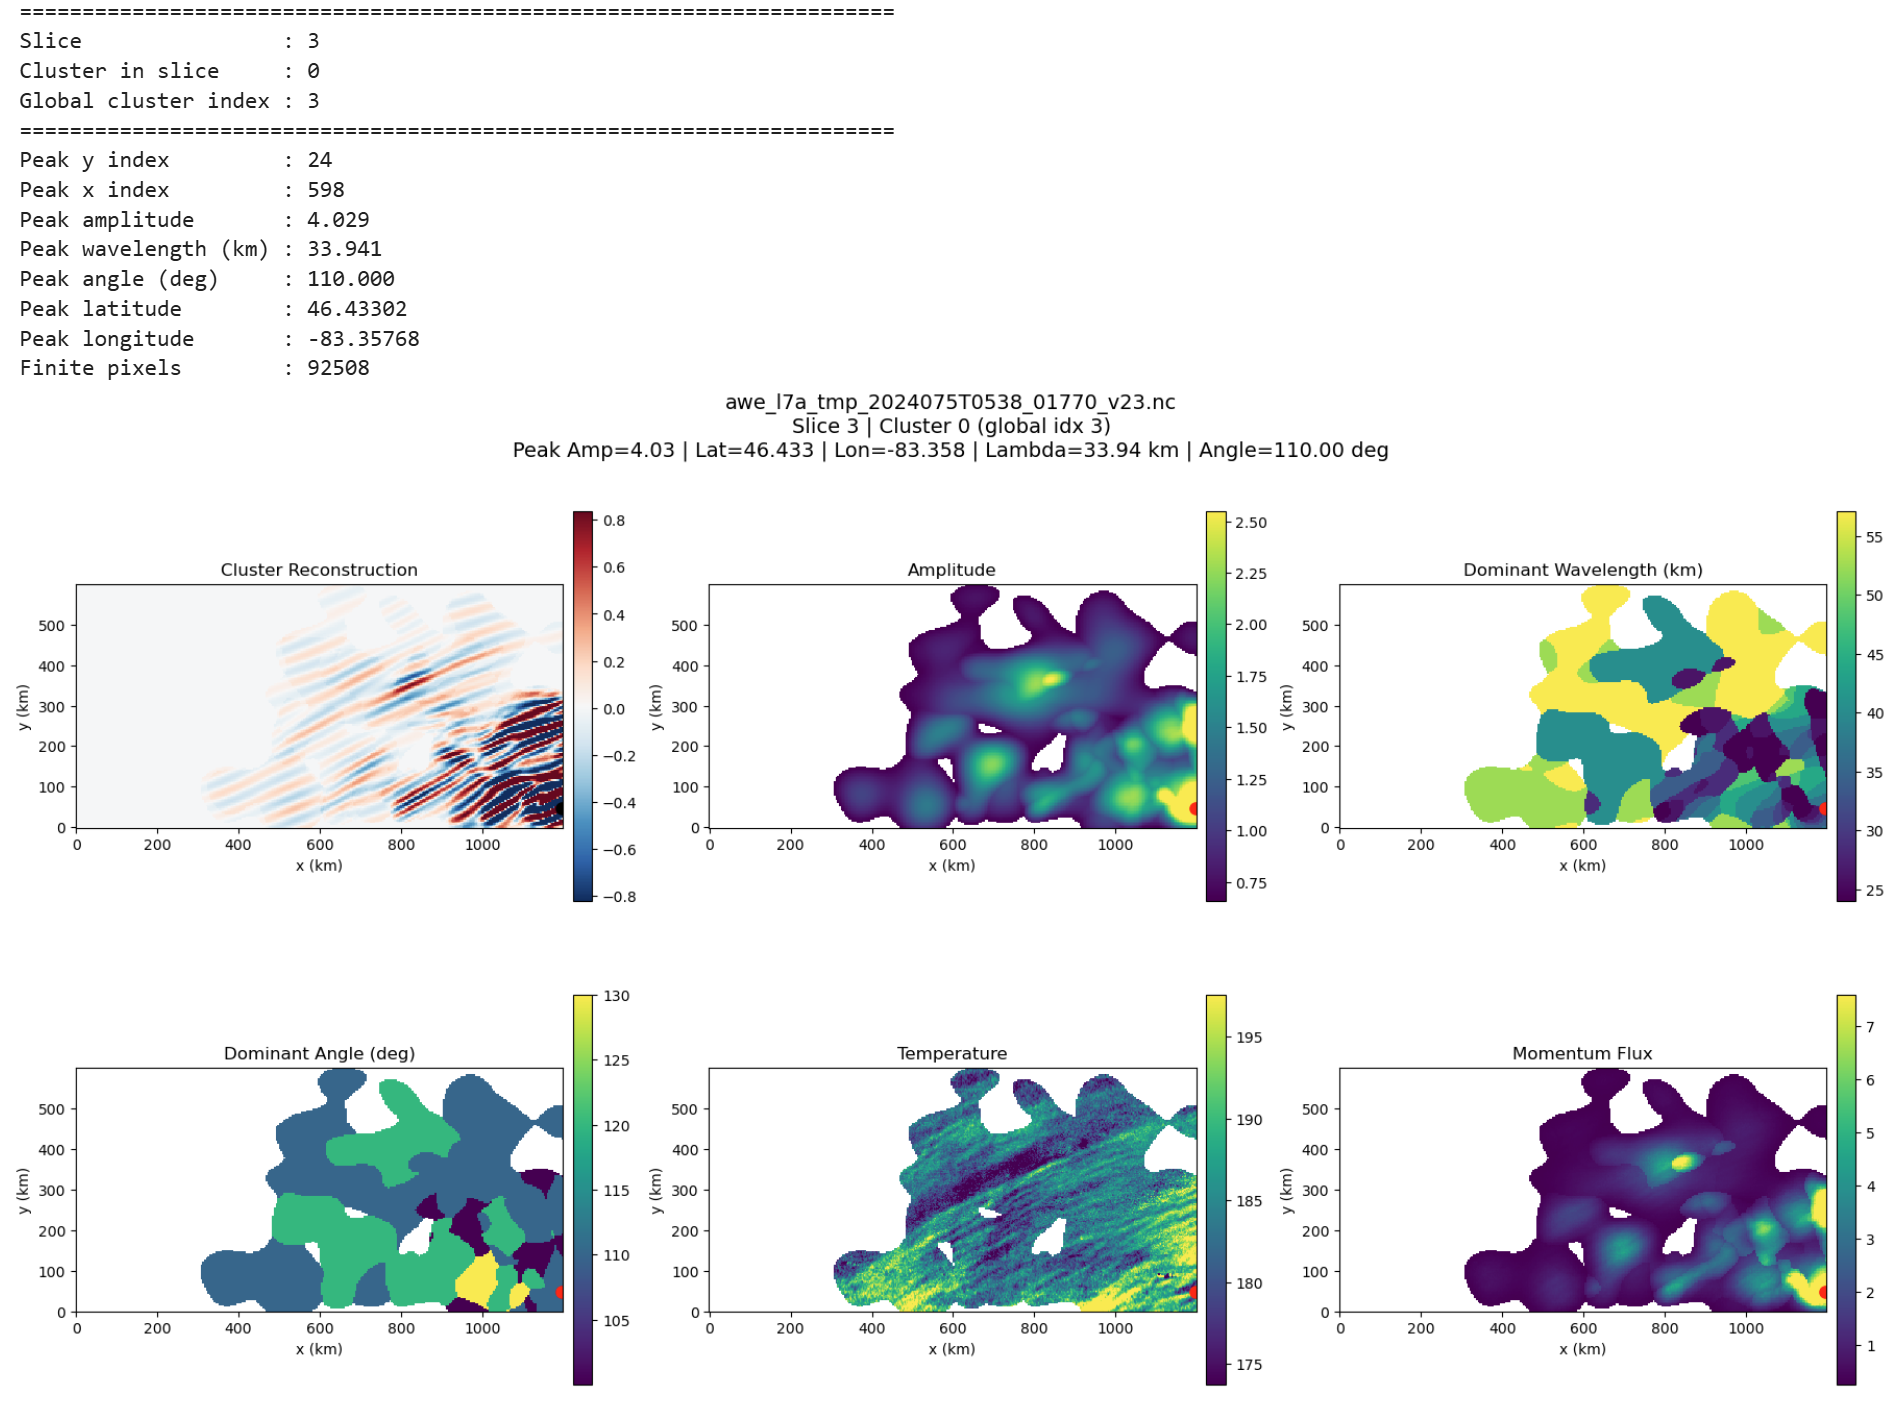

However, for this specific case, the peak is near the bottom edge of the swath. If we use this location for phase speed analysis, the frames will look like this: 

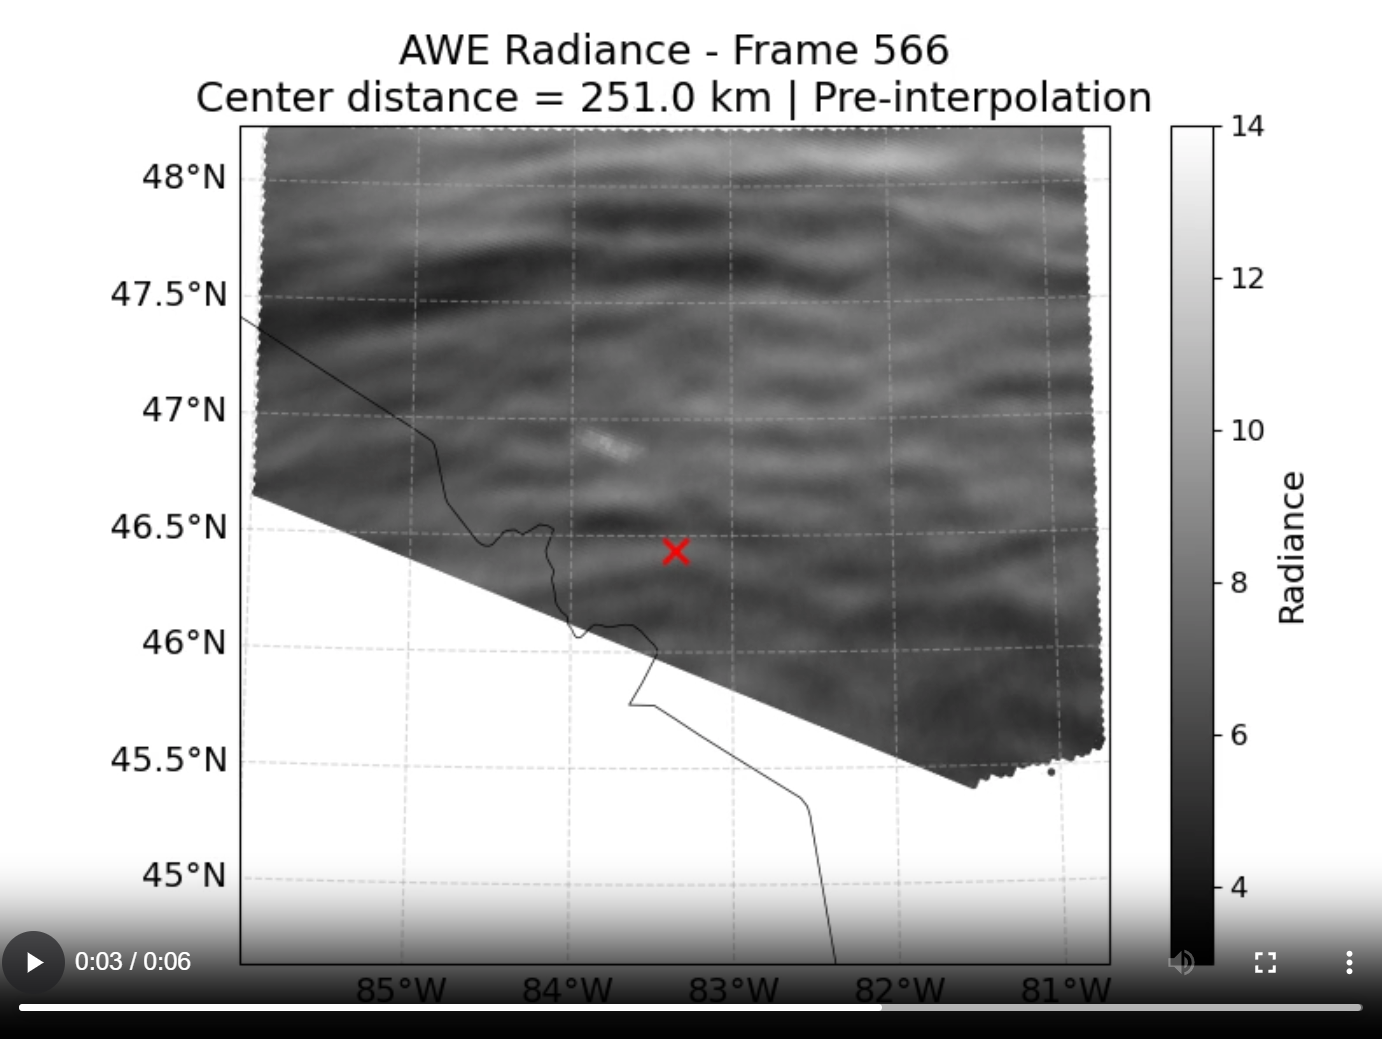

## Use "Representative peak"

    """
    Pick one point for the cluster.

    Method code:
    Selection method code:
        -1 = not saved
         1 = selected max amplitude inside y band 150-450
         2 = fallback point closest to y band 150-450, max amp if tie
        """

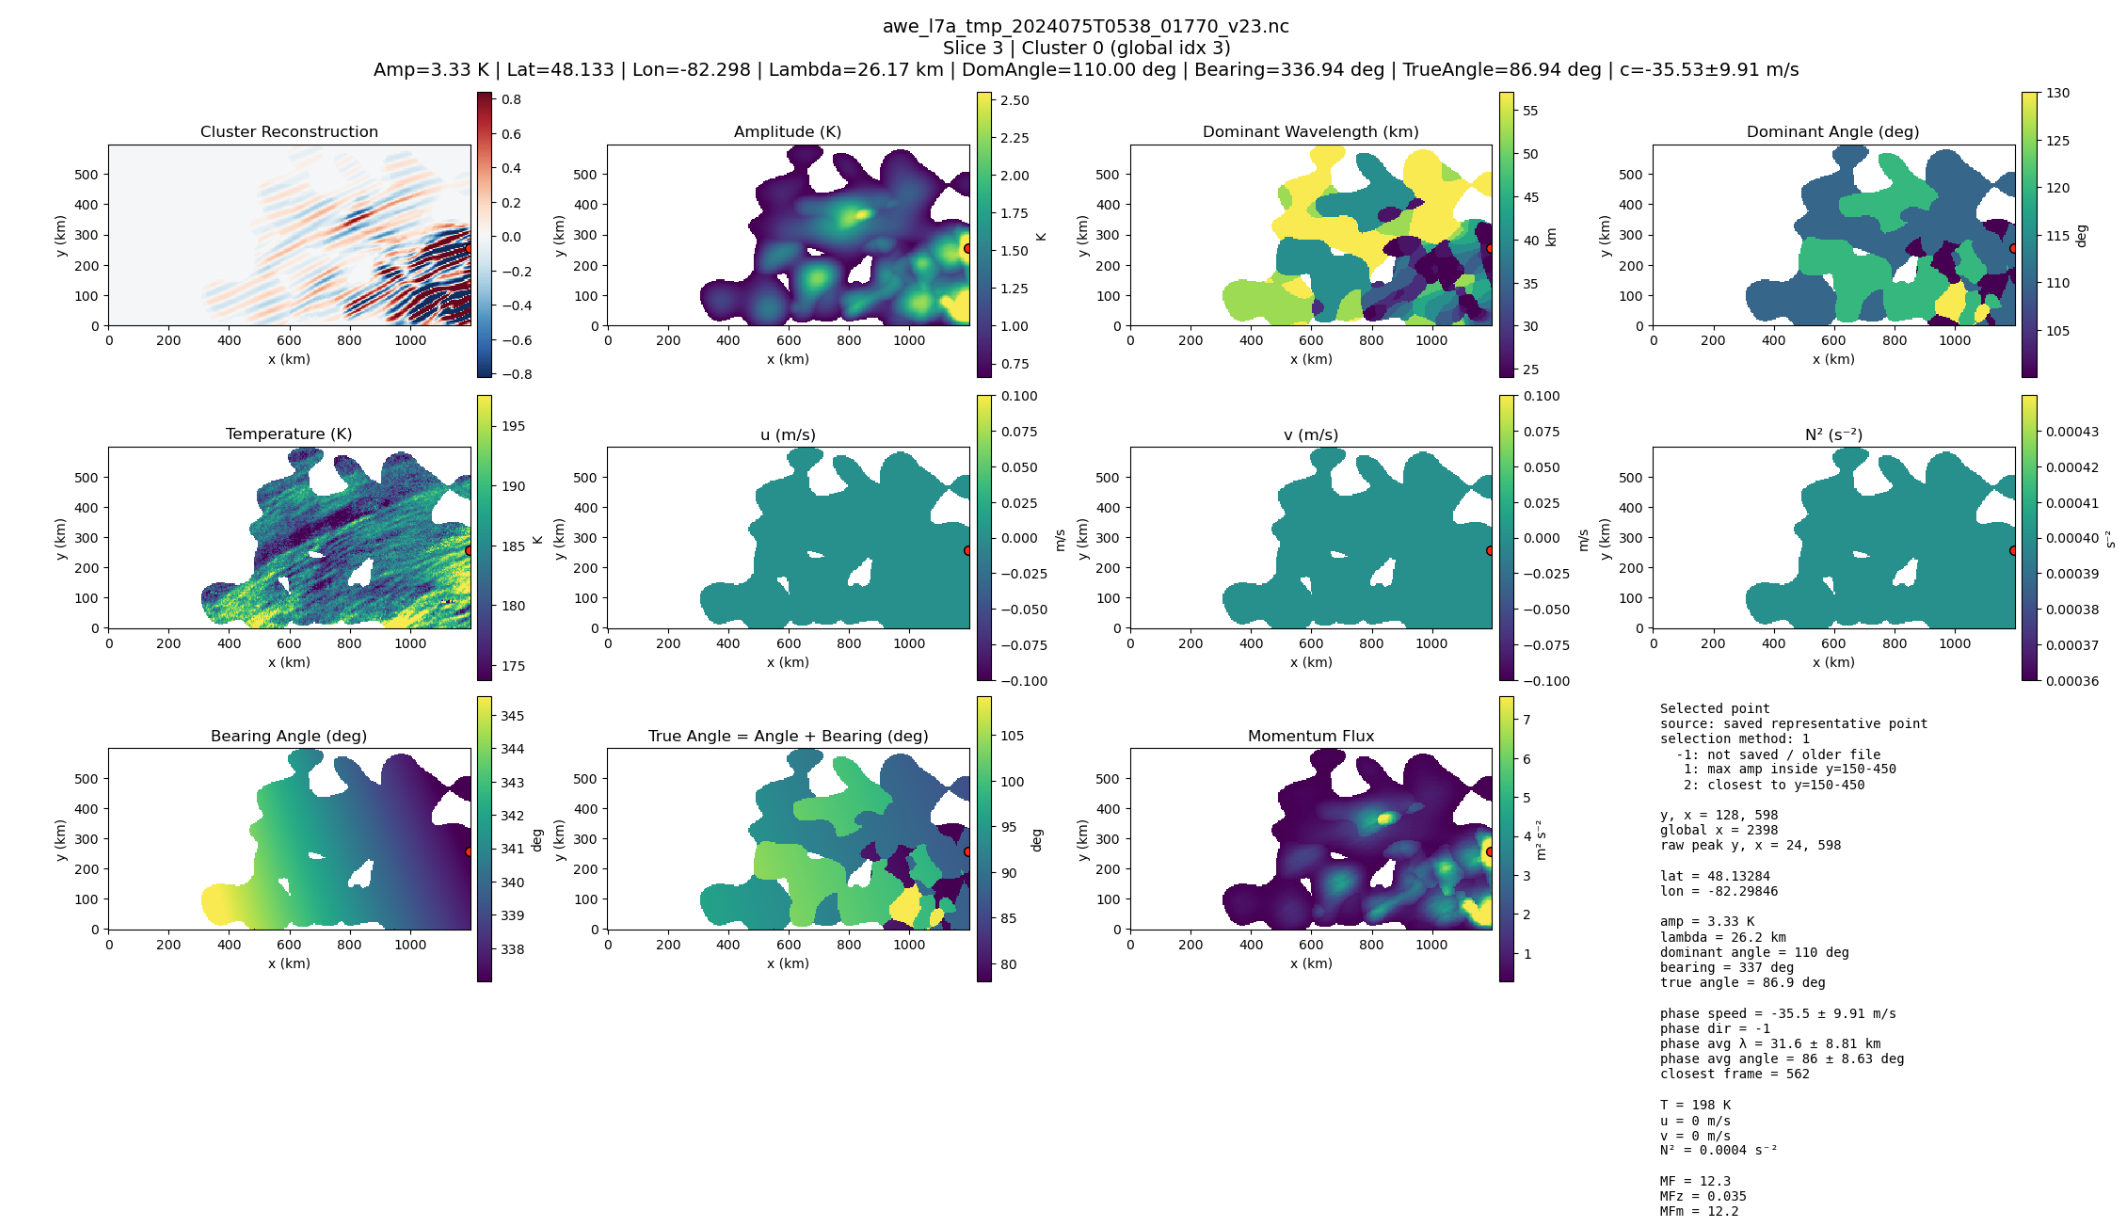

## Loop
* Try multiple clusters in the same slice
* Try multiple clusters in all slices

It took 4.5 hours to analyze the whole orbit with 142 clusters. (Probably too many clusters, some of the same waves overlapping) => Set a limit and maybe combine similar clusters together. 

## What went wrong here? 

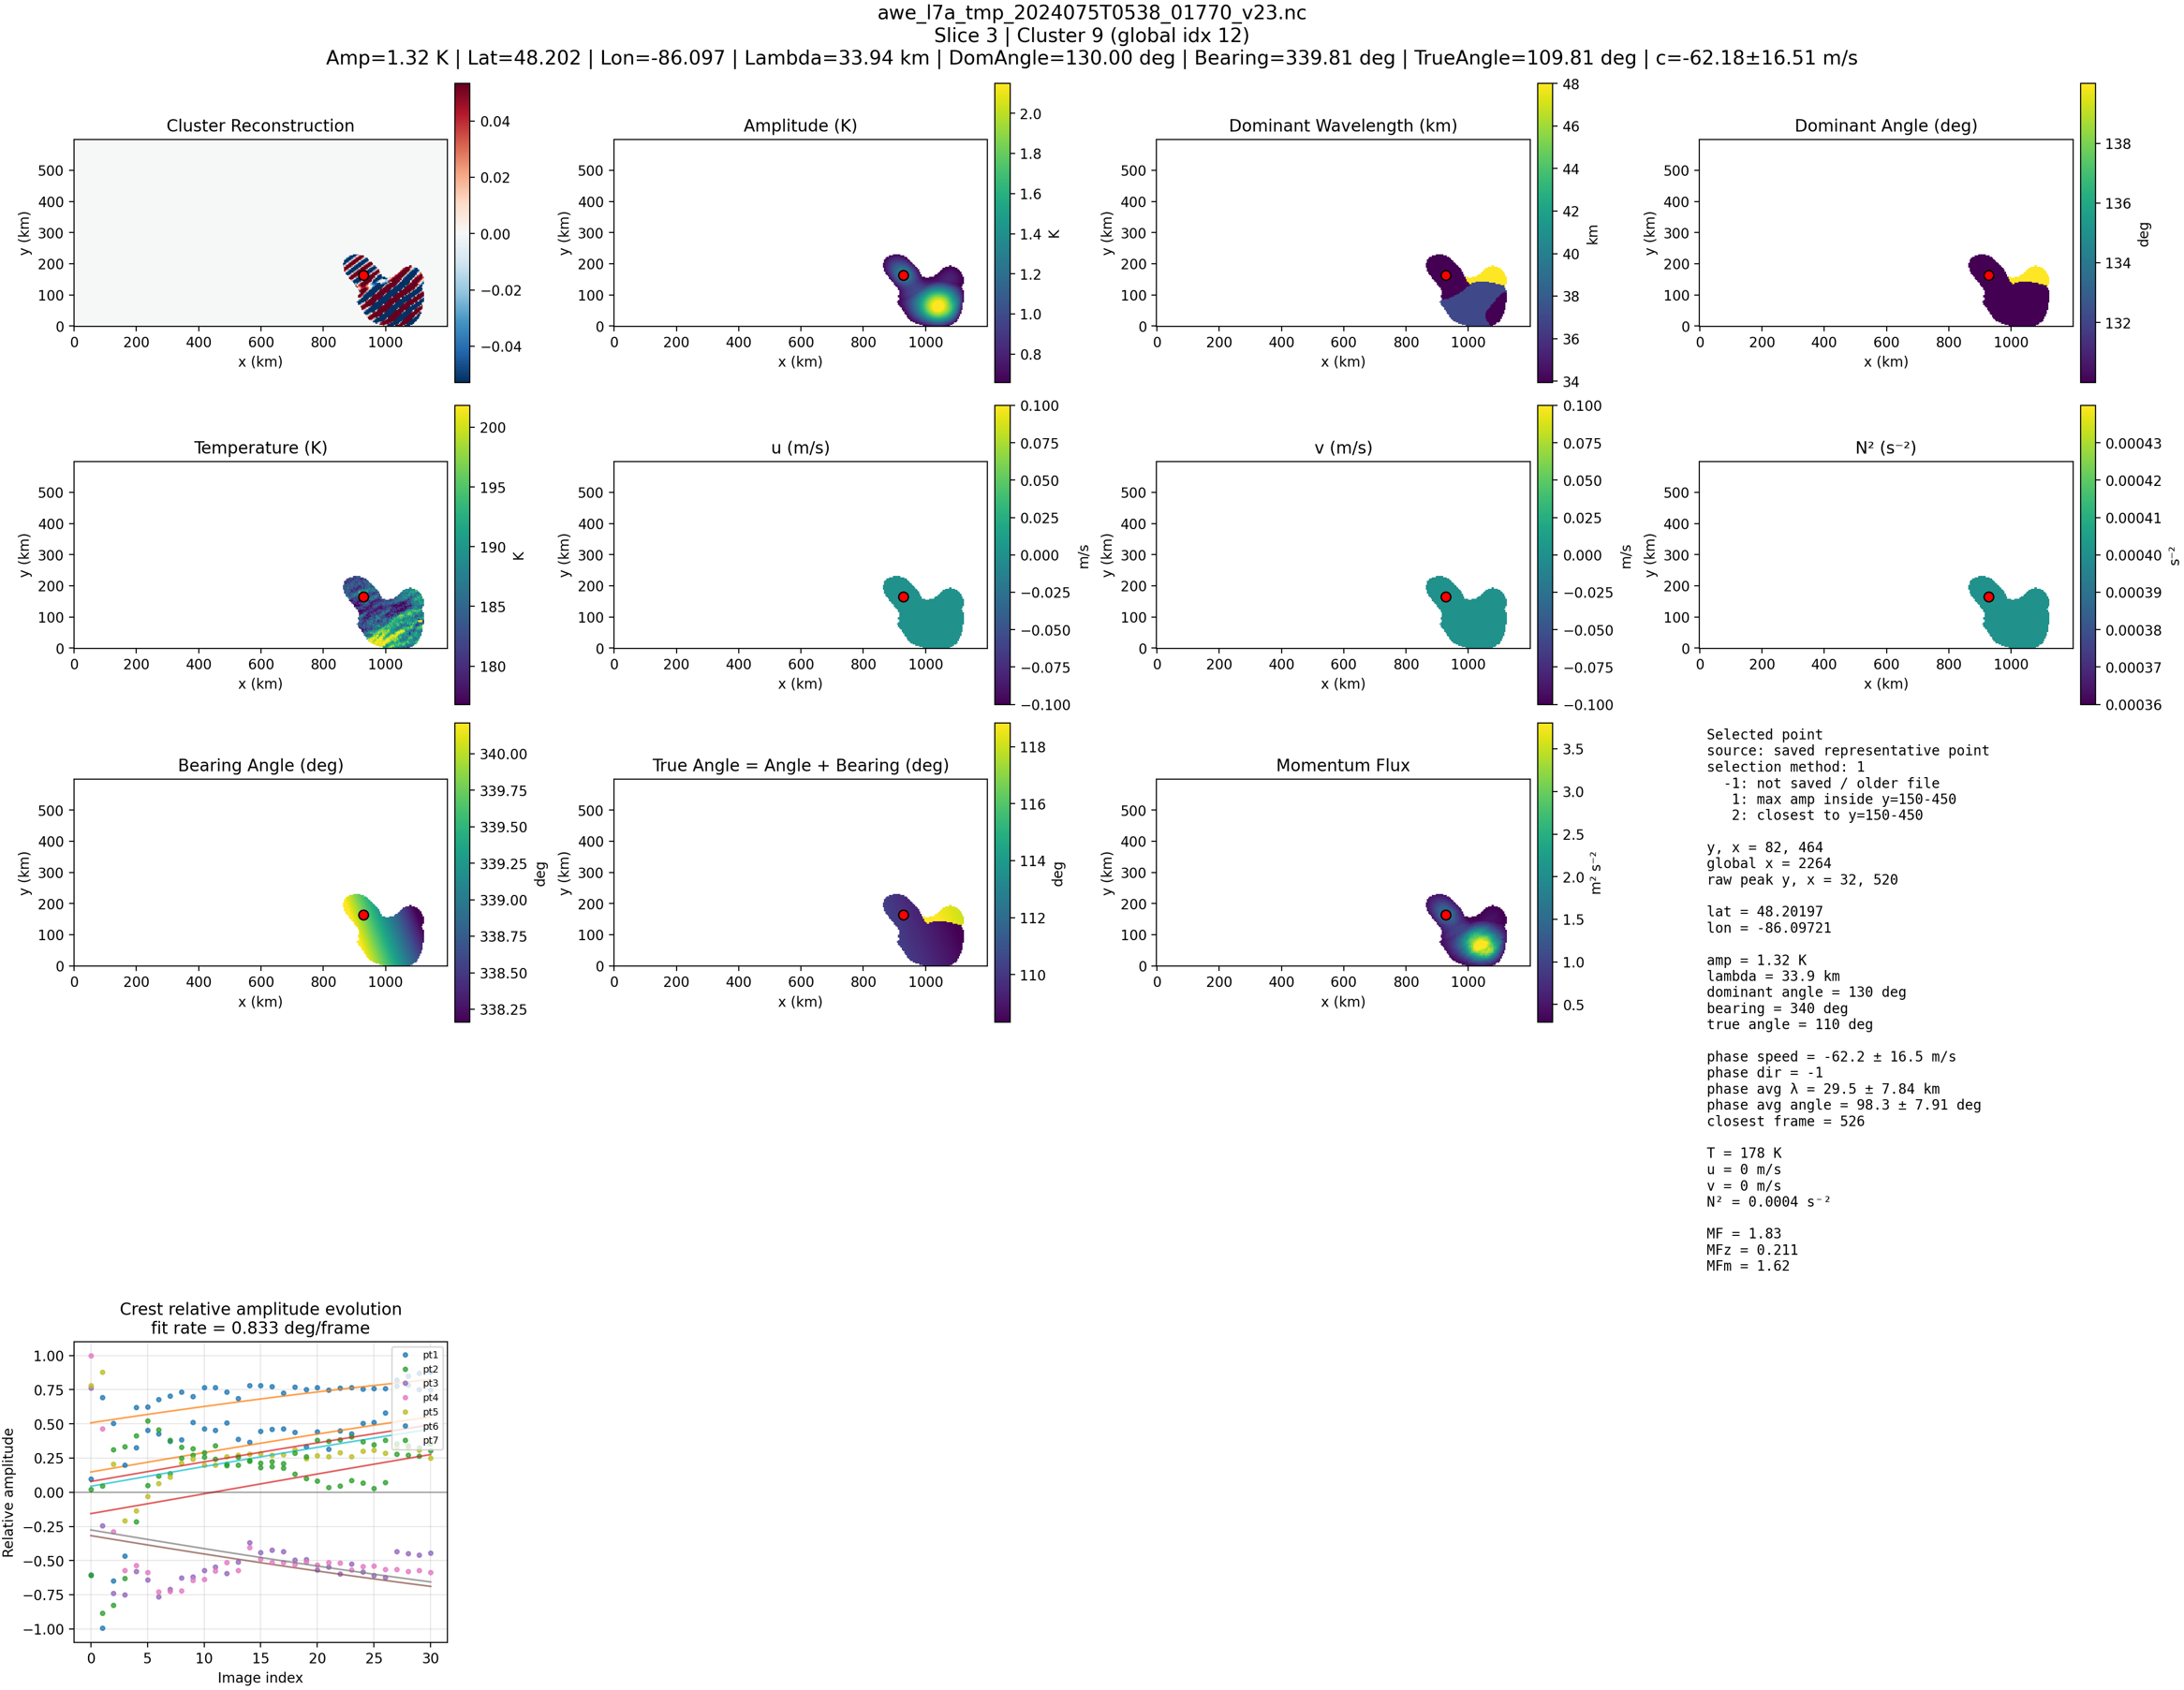

The peak amplitude is pretty close to the edge.

First frame:

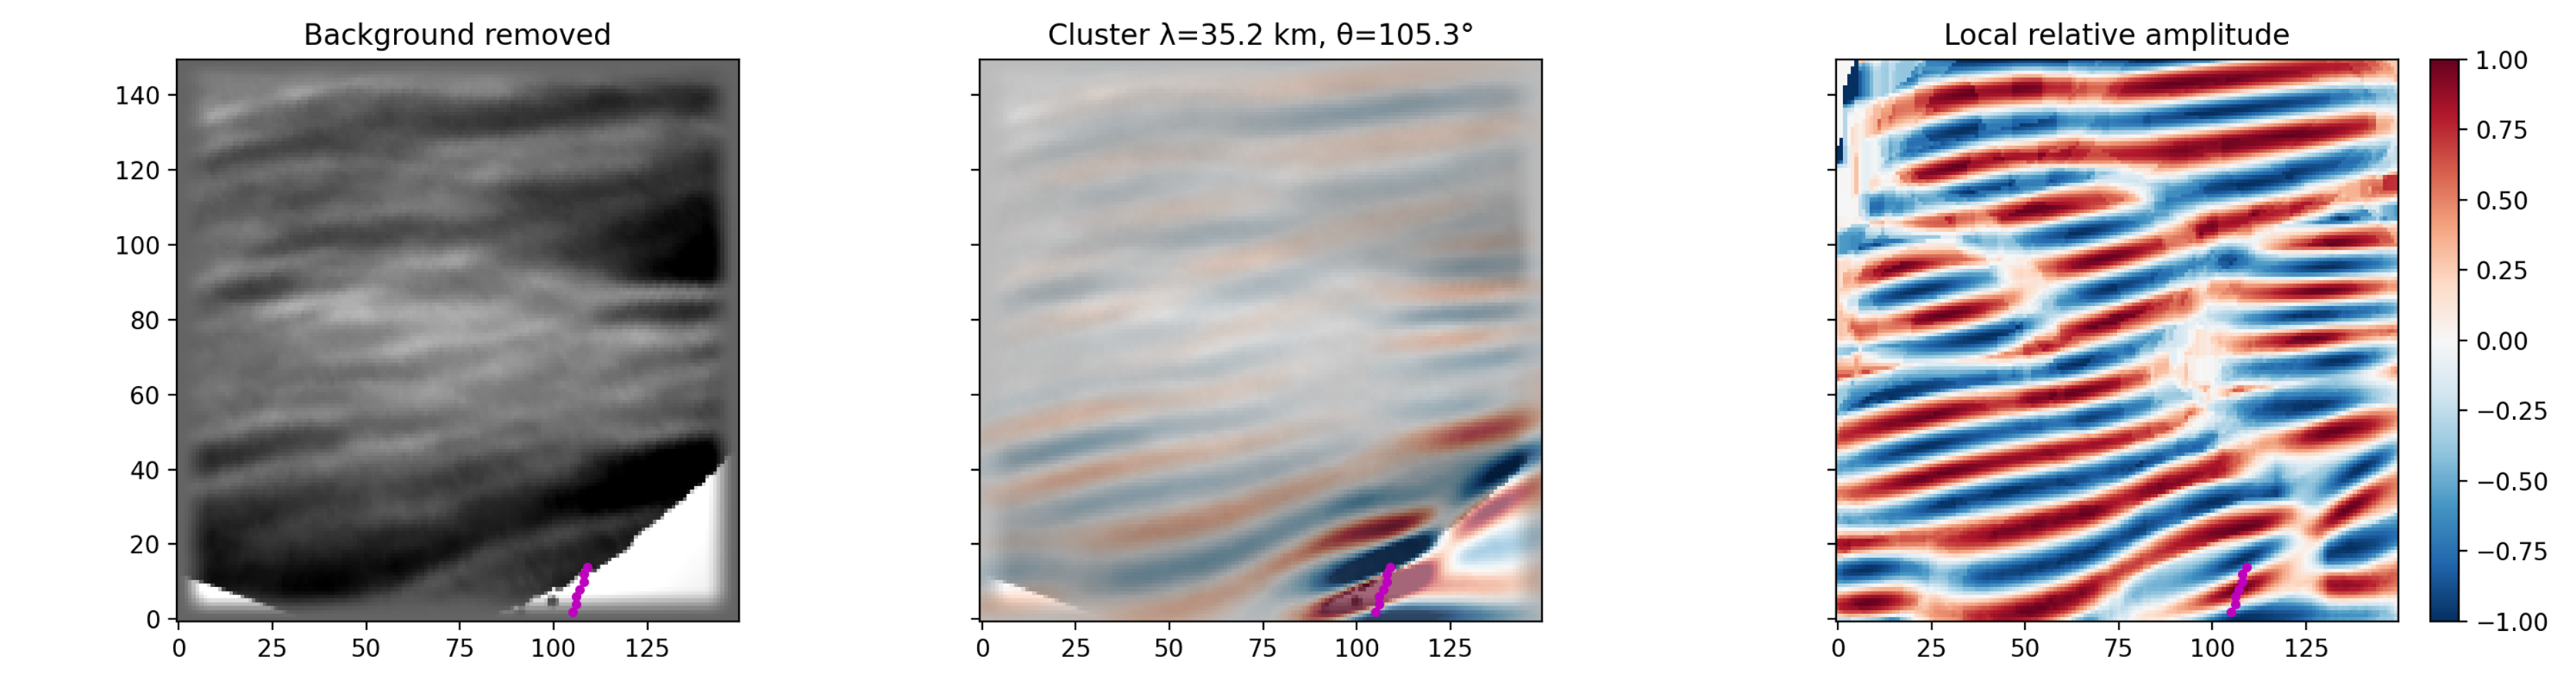

Fake waves because of the edge of FOV. 

For smaller wavelengths, it's better to reduce the size (crop to a smaller image) or find a way to move ROI to an adjacent ROI. 

Faster analying as well, because of the reduced size. 

## After reducing ROI size: 

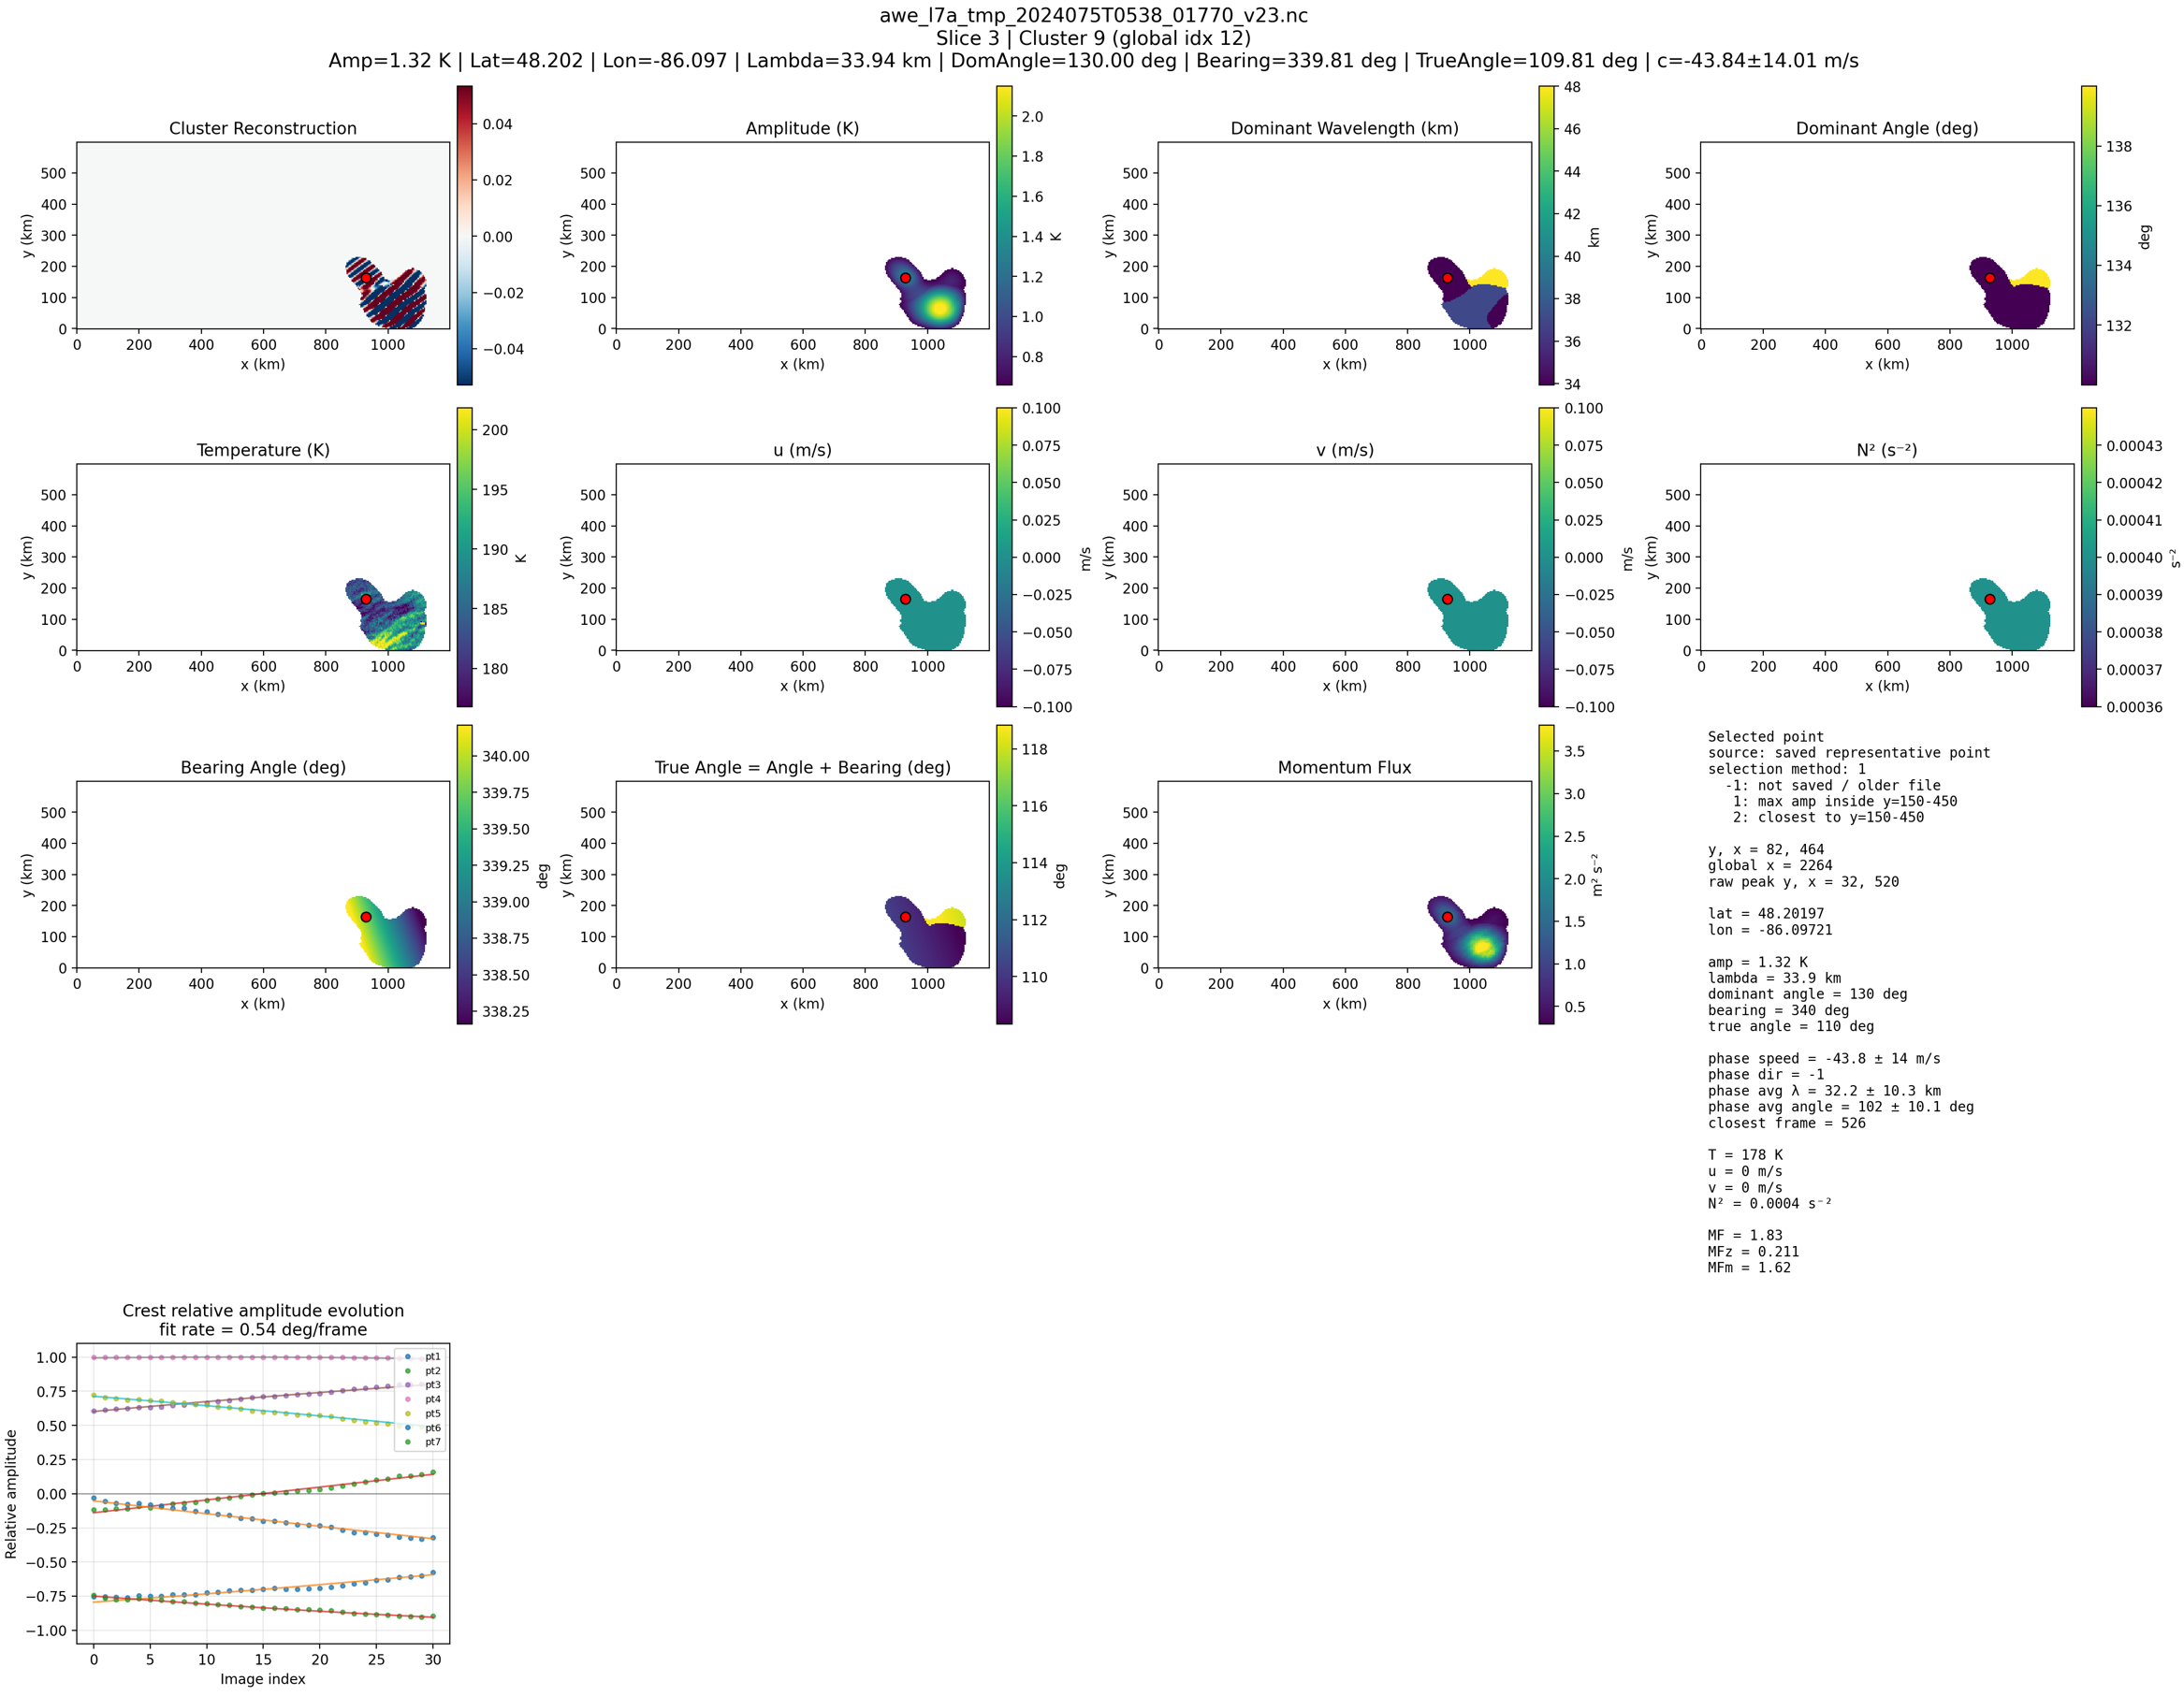

But: 
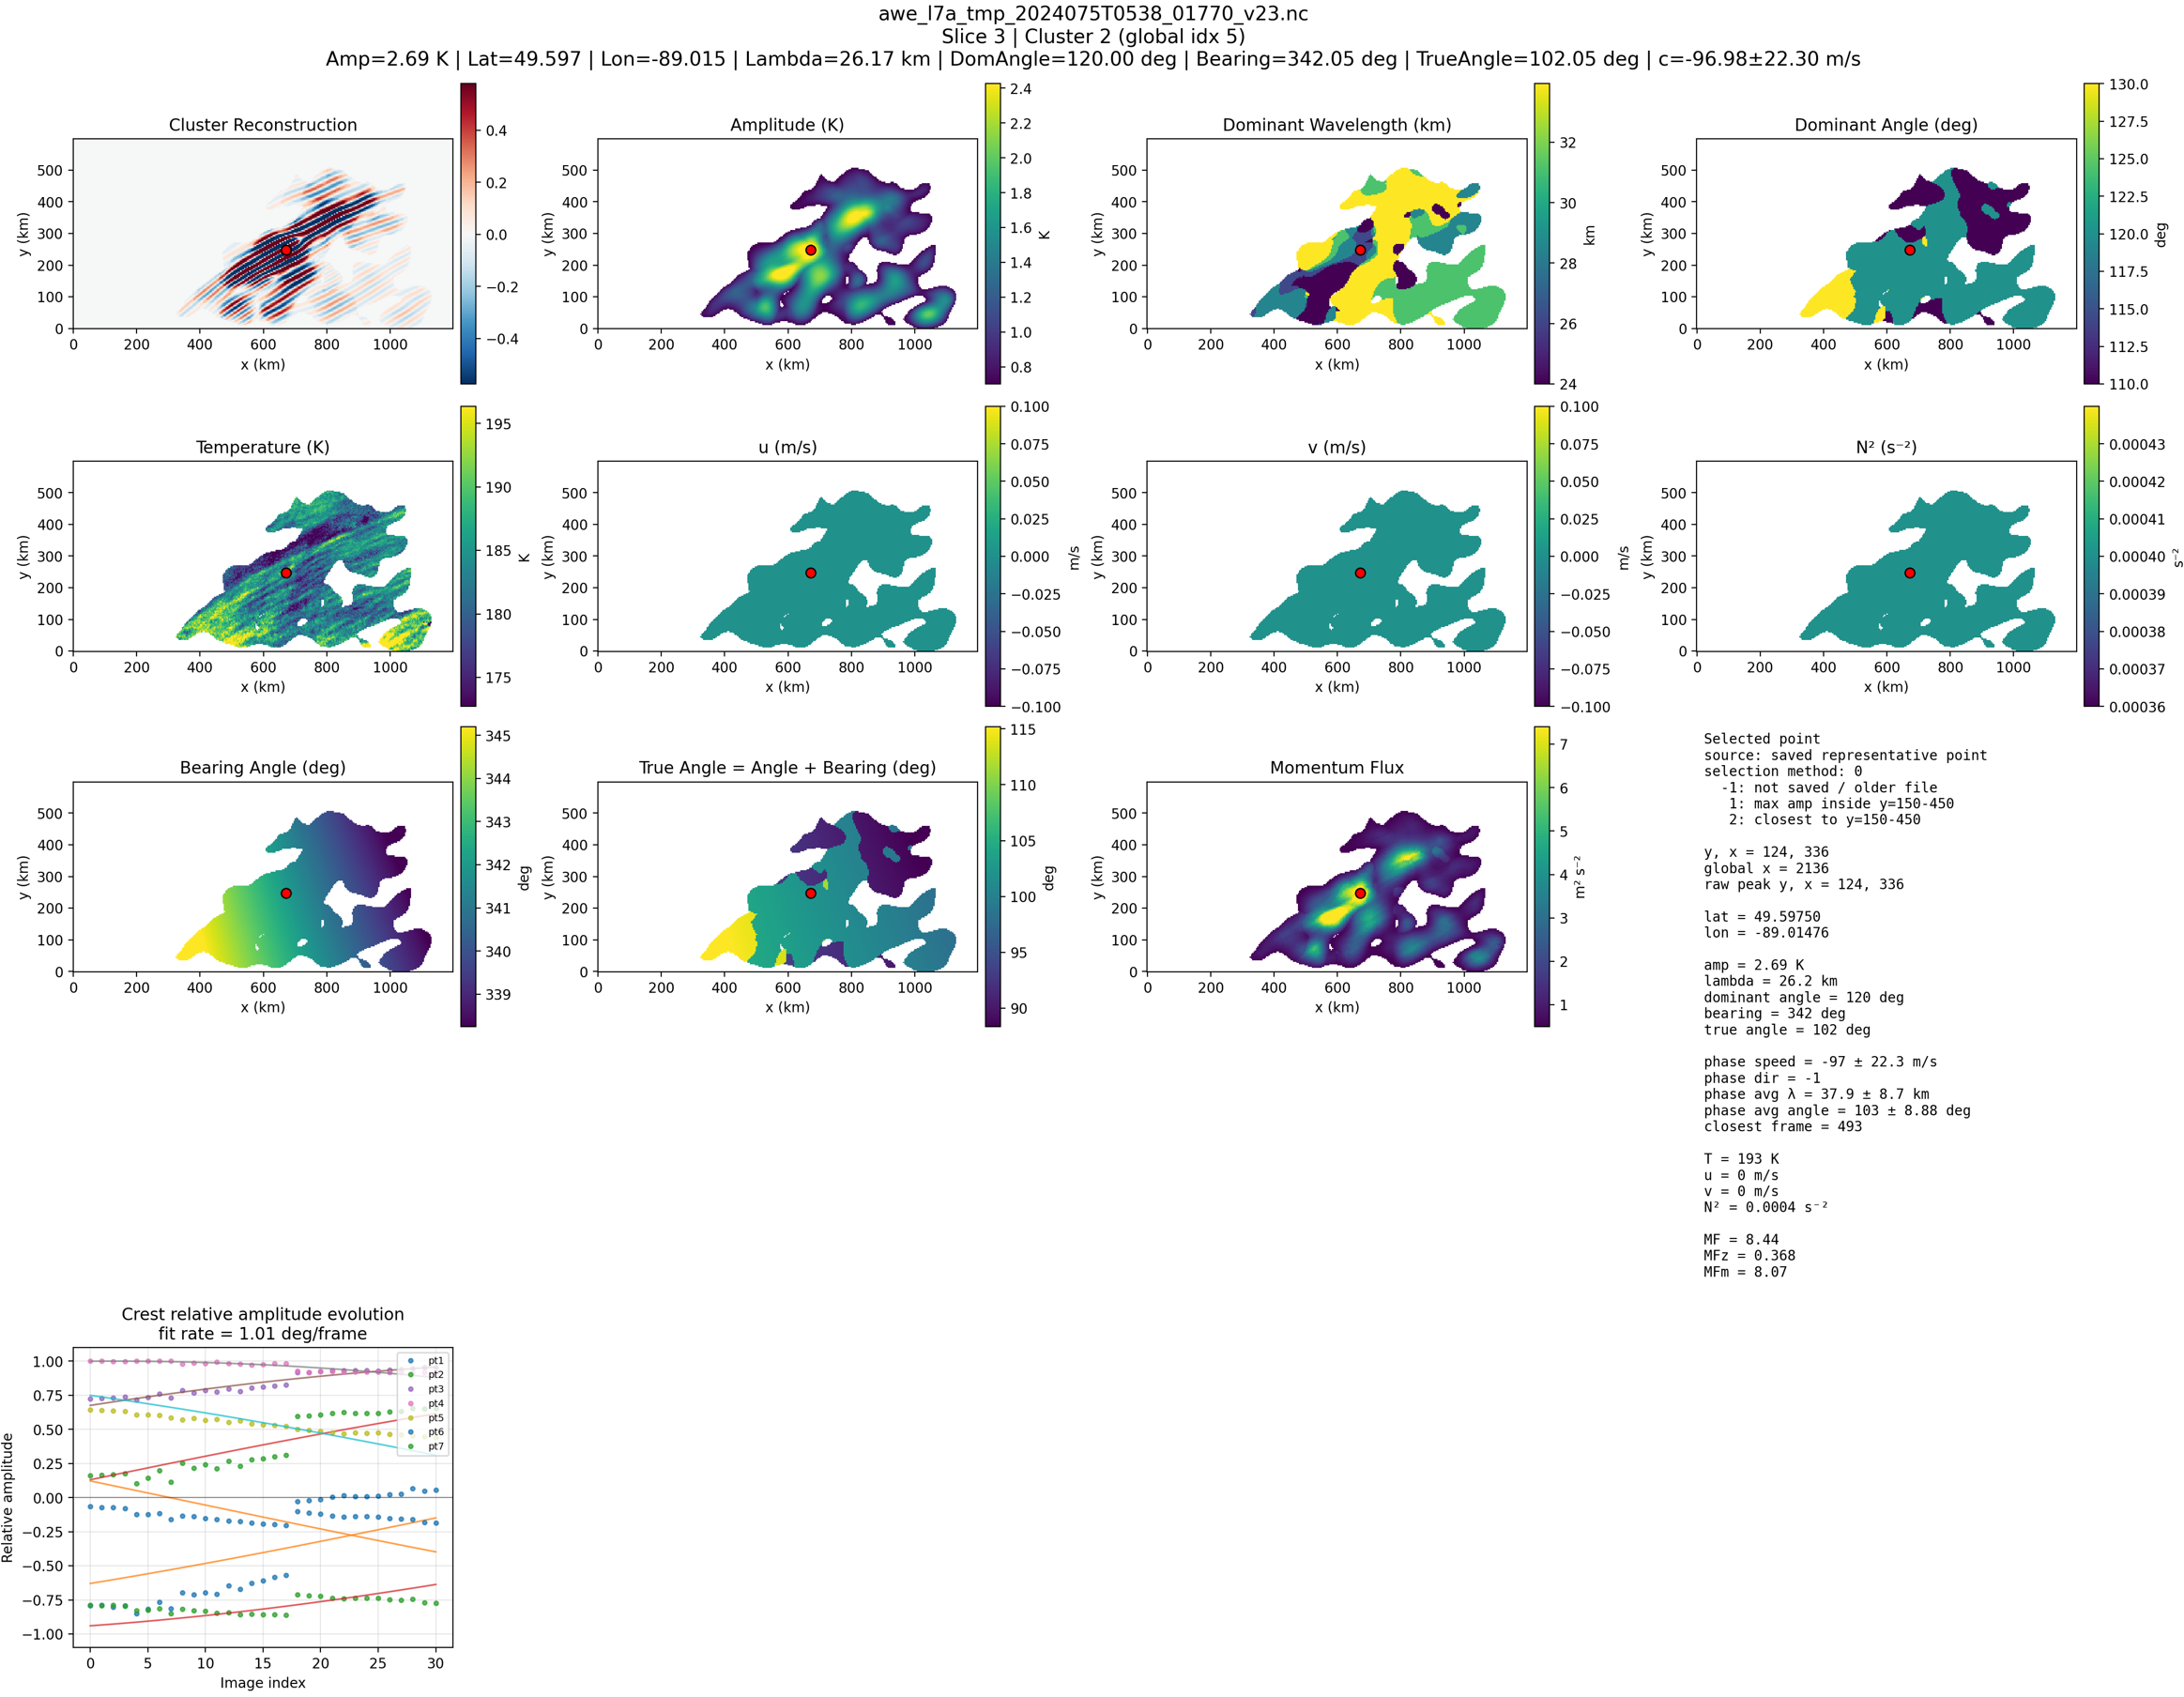

## Changing wavelength steps

Currently, the way I search for the corresponding L1A wave is:

* Get the target angle and wavelength.
* If the target wavelength is 22.6 km, choose the nearest (2^n) value, which in this case is 16 km.
* The CWT wavelength range is then set from 8 km to 32 km, using 16 equally spaced steps in log scale.

### New approach

Instead of centering the wavelength range around the nearest (2^n) value, center it around the actual target wavelength.

Example:

* Target wavelength = 22.6 km
* Use a narrower wavelength range centered on 22.6 km
* New wavelength range: 16 km to 32 km
* Use 8 equally spaced steps in log scale
* Ensure that 22.6 km is the center wavelength of the range

So now:

* Old:

  * center = nearest power of 2 (16 km)
  * range = 8 to 32 km
  * 16 log-spaced steps

* New:

  * center = target wavelength itself (22.6 km)
  * range chosen around target wavelength
  * 8 log-spaced steps
  * target wavelength placed at the center of the wavelength grid


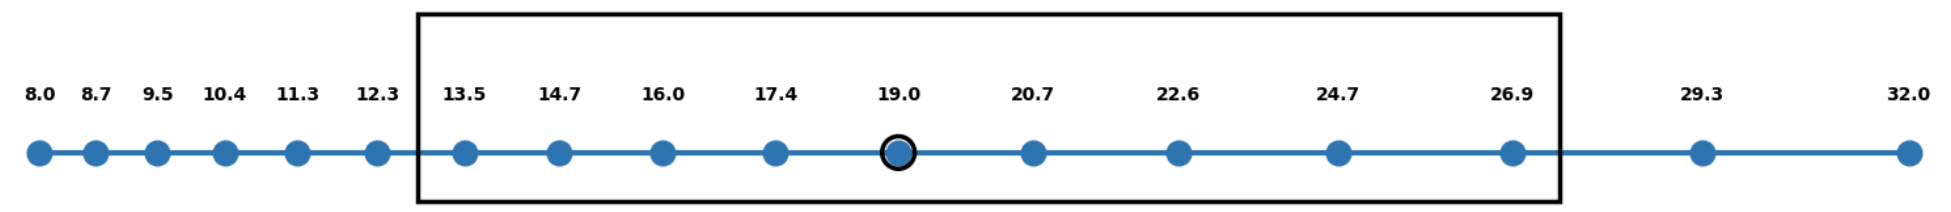

Does the whole cluster move at the same speed? 
Same value for phase speed c, different values for wind speed u? 

Or is c-u constant for the whole cluster? 